<img src="../../images/bwHPC_Logo_cmyk.svg" width="200" /> <img src="../../images/HochschuleEsslingen_Logo_RGB_DE.png" width="200" /> <img src="../../images/Konstanz_Logo.svg" width="200" /> <img src="../../images/KIT_Logo.png" width="200" />

# Principal Component Analysis

Clustering, in the previous notebook, looked for groups. This notebook is about the
other classic unsupervised task: **dimensionality reduction** — describing data with
fewer numbers than it arrived with, while throwing away as little as possible.

The reason to want that is partly practical (fewer numbers are faster to work with)
and partly human: we can look at two dimensions, we can just about handle three, and
beyond that we are blind. A dataset with fifty measurements per row cannot be
plotted at all.

**Principal Component Analysis** is the standard tool for this, and here we use it
for the simplest possible version of the problem — going from three dimensions down
to two, on data where we can *see* what was lost.

---

## Contents

1. [The data: a mammoth skeleton](#data)
2. [Seeing it in three dimensions](#3d)
3. [What PCA does](#pca)
4. [From three dimensions to two](#reduce)
5. [How much survived?](#variance)

<a id="data"></a>
## 1. The data: a mammoth skeleton

Our dataset is a 3D scan of a **mammoth skeleton**, made available by the
Smithsonian Institution. Every row is one point on the surface of the skeleton, with
three columns: its x, y and z coordinate in space.

*Data source: [https://3d.si.edu/](https://3d.si.edu/)*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

mammoth = np.load("mammoth_data_small.npy")

print("shape:", mammoth.shape)
mammoth[:5].round(2)

shape: (10000, 3)


array([[430.83, 106.86,  24.49],
       [397.73,  99.29,  14.37],
       [480.5 ,  80.88, 131.56],
       [422.74,  87.72,  13.5 ],
       [414.84, 113.36,  78.06]])

In [2]:
print("x range:", mammoth[:, 0].min().round(1), "to", mammoth[:, 0].max().round(1))
print("y range:", mammoth[:, 1].min().round(1), "to", mammoth[:, 1].max().round(1))
print("z range:", mammoth[:, 2].min().round(1), "to", mammoth[:, 2].max().round(1))

x range: 61.1 to 568.9
y range: -171.9 to 172.0
z range: -22.1 to 169.6


<a id="3d"></a>
## 2. Seeing it in three dimensions

Here is what the scan looks like turned into a finished 3D rendering:

![Rotating mammoth](../../images/mammoth_rotating.gif)

*3D-visualization of the mammoth (image from https://adanayak.medium.com/)*

That is someone else's rendering, though, and an animation is awkward to work with.
We can plot the data more properly ourselves — matplotlib draws all 10,000 points in
three dimensions directly, which is a luxury we are about to lose.

The colouring runs through the points in the order they are stored, which makes the
structure of the skeleton easier to follow.

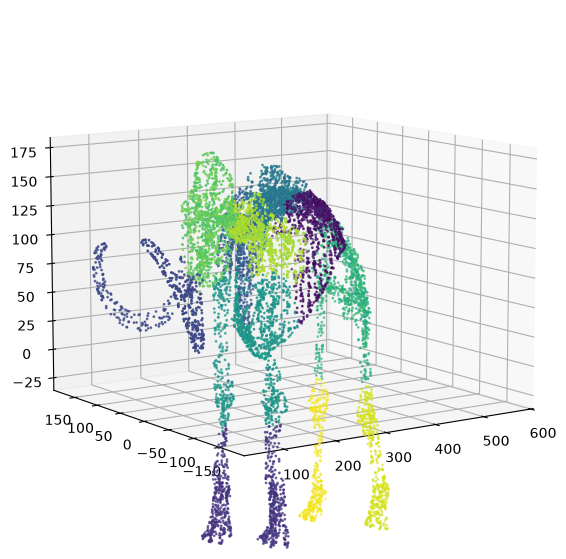

In [3]:
ax = plt.figure(figsize=(7, 7)).add_subplot(projection='3d')

ax.scatter(mammoth[:, 0], mammoth[:, 1], zs=mammoth[:, 2], zdir='y',
           c=np.arange(len(mammoth)), s=1)
ax.view_init(elev=10., azim=-125, roll=0)

plt.show()

A mammoth: legs, ribs, skull, tusks.

Now the question this notebook exists to answer. If we are only allowed **two**
numbers per point instead of three, which two should we keep?

<a id="pca"></a>
## 3. What PCA does

The naive answer is to drop a column — keep x and y, discard z. But that throws away
whatever was only visible along z, and the choice of which column to sacrifice is
arbitrary.

PCA does something smarter. Instead of keeping the original axes, it looks for
**new** ones, chosen to suit the data:

- the **first principal component** points in the direction in which the data is
  most spread out
- the **second** points in the direction of the greatest remaining spread, at right
  angles to the first
- and so on, one per original dimension

![Principal components](../../images/pca_components.svg)

Spread is the thing being preserved because spread is what distinguishes points from
each other. A direction in which every point has nearly the same value tells you
almost nothing, and is the one worth dropping.

Reducing to two dimensions then means keeping the first two components and
discarding the rest — an informed choice rather than an arbitrary one.

> PCA computes these directions with a **singular value decomposition** of the data.
> For a visual explanation of what that means, the
> [StatQuest](https://www.youtube.com/watch?v=HMOI_lkzW08) and
> [Steve Brunton](https://www.youtube.com/watch?v=fkf4IBRSeEc) videos are both
> excellent.

<a id="reduce"></a>
## 4. From three dimensions to two

In scikit-learn this is two lines. `n_components=2` says how many dimensions to keep,
and `fit_transform` both works out the components and projects the data onto
them.

In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
mammoth_reduced = pca.fit_transform(mammoth)

print("before:", mammoth.shape)
print("after: ", mammoth_reduced.shape)

before: (10000, 3)
after:  (10000, 2)


30,000 numbers became 20,000. Each point now has two coordinates instead of three,
and those coordinates are positions along the two new axes rather than along the
original x, y and z.

In [6]:
mammoth_reduced[:5].round(2)

array([[42.76, 90.14],
       [16.75, 68.55],
       [97.22, 88.83],
       [44.3 , 69.44],
       [24.76, 88.55]])

And now the thing that makes this dataset such a good example — the result can
simply be looked at.

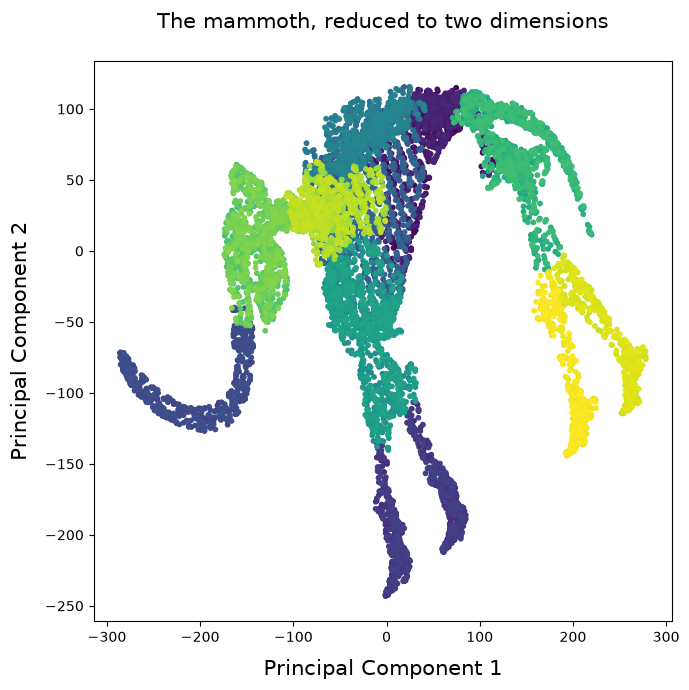

In [7]:
plt.figure(figsize=(7, 7))
plt.scatter(mammoth_reduced[:, 0], mammoth_reduced[:, 1],
            c=np.arange(len(mammoth_reduced)), s=10, linewidths=1)

plt.title("The mammoth, reduced to two dimensions\n", fontsize=15)
plt.xlabel("Principal Component 1", labelpad=10, fontsize=15)
plt.ylabel("Principal Component 2", labelpad=10, fontsize=15)
plt.tight_layout()
plt.show()

It is still recognisably a mammoth. A whole dimension was removed and the animal
survived — because PCA chose the two directions along which the skeleton is most
spread out, and a mammoth is much longer and taller than it is wide.

This is also a fair warning about what reduction costs. The result is a silhouette:
everything that distinguished the near side from the far side is gone, and points
that were far apart in the discarded direction now sit on top of each other.

<a id="variance"></a>
## 5. How much survived?

That question has a numerical answer. PCA records how much of the data's total
spread each component accounts for.

In [8]:
print(f"Variance along PC 1: {pca.explained_variance_ratio_[0]:.3f}")
print(f"Variance along PC 2: {pca.explained_variance_ratio_[1]:.3f}")
print(f"Kept in the first two components: {pca.explained_variance_ratio_.sum():.1%}")

Variance along PC 1: 0.596
Variance along PC 2: 0.348
Kept in the first two components: 94.4%


That percentage is the honest summary of the trade: it says how much of the original
variation the two-dimensional version still carries, and by subtraction how much was
thrown away with the third dimension.

For a skeleton the loss is easy to judge, because we can look at the picture and see
what happened. The reason this example is worth doing is that it builds the intuition
for the cases where you *cannot* look — fifty measurements per row, reduced to two,
with only the explained-variance ratio to tell you whether the reduction was
reasonable.